In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_transformer, ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC                                   
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split, GridSearchCV


In [2]:
train_df = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")

In [3]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
train_df.describe(include=["O"])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


In [6]:
train_df.groupby(['Pclass'], as_index=True)['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

<Axes: xlabel='Survived', ylabel='count'>

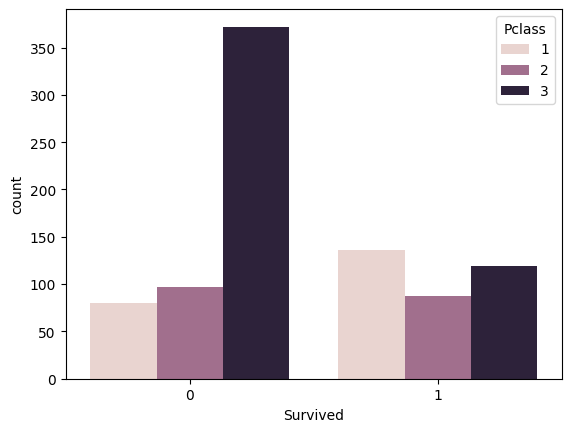

In [7]:
sns.countplot(x="Survived", hue="Pclass", data=train_df)

In [8]:
train_df.groupby(['Sex'], as_index=True)['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

<Axes: xlabel='Survived', ylabel='count'>

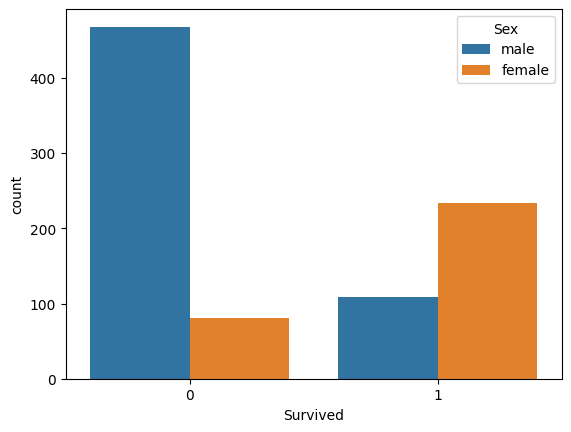

In [9]:
sns.countplot(x="Survived", hue="Sex", data=train_df)

In [10]:
train_df.groupby(['SibSp'], as_index=True)['Survived'].mean()

SibSp
0    0.345395
1    0.535885
2    0.464286
3    0.250000
4    0.166667
5    0.000000
8    0.000000
Name: Survived, dtype: float64

<Axes: xlabel='Survived', ylabel='count'>

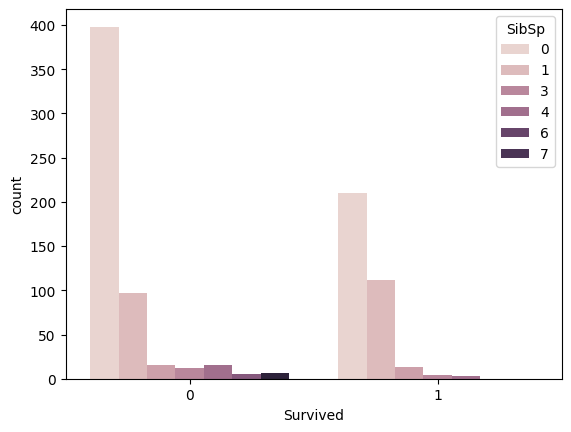

In [11]:
sns.countplot(x="Survived", hue="SibSp", data=train_df)

In [12]:
train_df.groupby(['Parch'], as_index=True)['Survived'].mean()

Parch
0    0.343658
1    0.550847
2    0.500000
3    0.600000
4    0.000000
5    0.200000
6    0.000000
Name: Survived, dtype: float64

<Axes: xlabel='Survived', ylabel='count'>

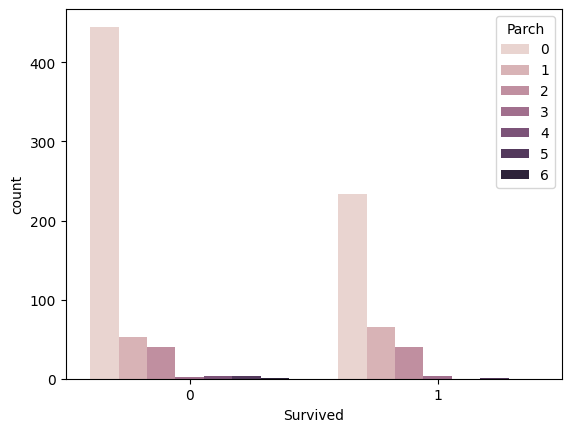

In [13]:
sns.countplot(x="Survived", hue="Parch", data=train_df)

In [14]:
train_df["Age"] = train_df["Age"].fillna(train_df["Age"].median())
test_df["Age"] = test_df["Age"].fillna(test_df["Age"].median())

train_df["Embarked"] = train_df["Embarked"].fillna(train_df["Embarked"].mode()[0])
test_df["Embarked"] = test_df["Embarked"].fillna(test_df["Embarked"].mode()[0])

In [15]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [16]:
train_df = train_df.drop(columns=["Cabin"])
test_df = test_df.drop(columns=["Cabin"])

In [17]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S


In [18]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [19]:
train_df['Family_Size'] = train_df['SibSp'] + train_df['Parch'] + 1
test_df['Family_Size'] = test_df['SibSp'] + test_df['Parch'] + 1

In [20]:
train_df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Family_Size
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,Q,1
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S,1
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S,5
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S,3
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C,2


In [21]:
train_df.groupby(['Family_Size'], as_index = False)['Survived'].mean()

,Family_Size,Survived
0,1,0.303538
1,2,0.552795
2,3,0.578431
3,4,0.724138
4,5,0.200000
5,6,0.136364
6,7,0.333333
7,8,0.000000
8,11,0.000000


In [22]:
family_map = { 1: 'Alone', 2: 'Small', 3: 'Small', 4: 'Small', 5: 'Medium', 6: 'Medium', 7: 'Large', 8: 'Large', 11: 'Large'}
train_df['Family_Size_Grouped'] = train_df["Family_Size"].map(family_map)
test_df['Family_Size_Grouped'] = test_df["Family_Size"].map(family_map)

In [23]:
train_df.groupby(['Family_Size_Grouped'], as_index = False)['Survived'].mean()

,Family_Size_Grouped,Survived
0,Alone,0.303538
1,Large,0.160000
2,Medium,0.162162
3,Small,0.578767


In [24]:
train_df.groupby(['Embarked'], as_index = False)['Survived'].mean()

,Embarked,Survived
0,C,0.553571
1,Q,0.389610
2,S,0.339009


In [25]:
# split data into equal-sized groups based on percentiles
# train_df['Age_Cut'] = pd.qcut(train_df["Age"], 8)
# test_df['Age_Cut'] = pd.qcut(test_df["Age"], 8)
train_df['Age_Cut'], bins = pd.qcut(train_df["Age"], 8, retbins=True, duplicates="drop")

test_df['Age_Cut'] = pd.cut(test_df["Age"], bins=bins)

In [26]:
train_df.groupby(['Age_Cut'], as_index = False)['Survived'].mean()

/tmp/ipykernel_55/1359979237.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df.groupby(['Age_Cut'], as_index = False)['Survived'].mean()


,Age_Cut,Survived
0,"(0.419, 17.0]",0.539823
1,"(17.0, 22.0]",0.313559
2,"(22.0, 27.0]",0.405660
3,"(27.0, 28.0]",0.292079
4,"(28.0, 29.0]",0.363636
5,"(29.0, 35.0]",0.451327
6,"(35.0, 45.0]",0.394737
7,"(45.0, 80.0]",0.368932


In [27]:
# train_df.loc[train_df['Age'] <= 17, 'Age'] = 0
# train_df.loc[(train_df['Age'] > 17) & (train_df['Age'] <= 22) , 'Age'] = 1
# train_df.loc[(train_df['Age'] > 22) & (train_df['Age'] <= 27) , 'Age'] = 2
# train_df.loc[(train_df['Age'] > 27) & (train_df['Age'] <= 28) , 'Age'] = 3
# train_df.loc[(train_df['Age'] > 28) & (train_df['Age'] <= 29) , 'Age'] = 4
# train_df.loc[(train_df['Age'] > 29) & (train_df['Age'] <= 35) , 'Age'] = 5
# train_df.loc[(train_df['Age'] > 35) & (train_df['Age'] <= 45) , 'Age'] = 6
# train_df.loc[(train_df['Age'] > 45) & (train_df['Age'] <= 80) , 'Age'] = 7
# train_df.loc[train_df['Age'] > 80, 'Age']

# test_df.loc[test_df['Age'] <= 17, 'Age'] = 0
# test_df.loc[(test_df['Age'] > 17) & (test_df['Age'] <= 22) , 'Age'] = 1
# test_df.loc[(test_df['Age'] > 22) & (test_df['Age'] <= 27) , 'Age'] = 2
# test_df.loc[(test_df['Age'] > 27) & (test_df['Age'] <= 28) , 'Age'] = 3
# test_df.loc[(test_df['Age'] > 28) & (test_df['Age'] <= 29) , 'Age'] = 4
# test_df.loc[(test_df['Age'] > 29) & (test_df['Age'] <= 35) , 'Age'] = 5
# test_df.loc[(test_df['Age'] > 35) & (test_df['Age'] <= 45) , 'Age'] = 6
# test_df.loc[(test_df['Age'] > 45) & (test_df['Age'] <= 80) , 'Age'] = 7
# test_df.loc[test_df['Age'] > 80, 'Age']

bins = [0, 16, 20, 24, 28, 32, 38, 47, 80, float('inf')]
labels = range(9)

train_df["Age"] = pd.cut(train_df["Age"], bins=bins, labels=labels)
test_df["Age"] = pd.cut(test_df["Age"], bins=bins, labels=labels)

In [28]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Family_Size,Family_Size_Grouped,Age_Cut
0,1,0,3,"Braund, Mr. Owen Harris",male,2,1,0,A/5 21171,7.2500,S,2,Small,"(17.0, 22.0]"
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,5,1,0,PC 17599,71.2833,C,2,Small,"(35.0, 45.0]"
2,3,1,3,"Heikkinen, Miss. Laina",female,3,0,0,STON/O2. 3101282,7.9250,S,1,Alone,"(22.0, 27.0]"
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,5,1,0,113803,53.1000,S,2,Small,"(29.0, 35.0]"
4,5,0,3,"Allen, Mr. William Henry",male,5,0,0,373450,8.0500,S,1,Alone,"(29.0, 35.0]"


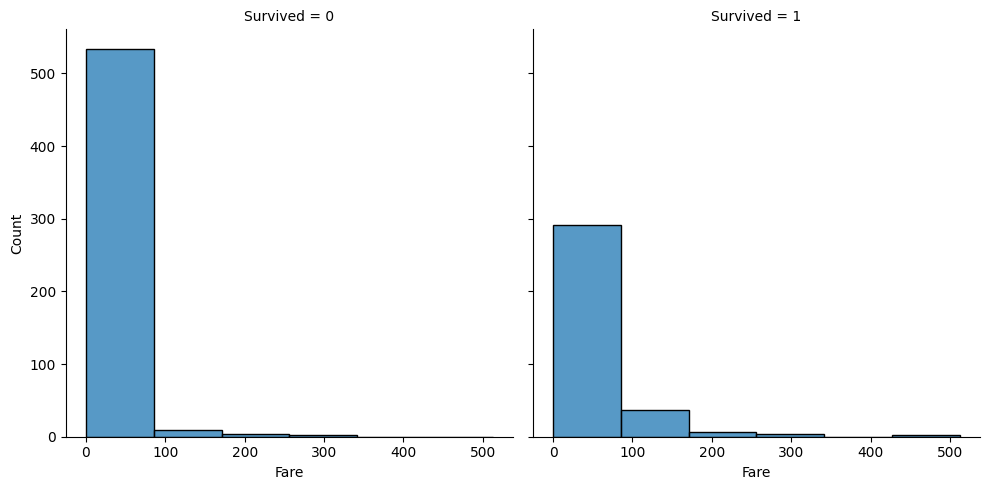

In [29]:
sns.displot(train_df, x="Fare", col ="Survived", binwidth=80, height=5)

In [30]:
train_df['Fare_Cut'] = pd.qcut(train_df["Fare"], 6)
test_df['Fare_Cut'] = pd.qcut(test_df["Fare"], 6)

In [31]:
train_df.groupby(['Fare_Cut'], as_index = False)['Survived'].mean()

/tmp/ipykernel_55/3334708280.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df.groupby(['Fare_Cut'], as_index = False)['Survived'].mean()


,Fare_Cut,Survived
0,"(-0.001, 7.775]",0.205128
1,"(7.775, 8.662]",0.190789
2,"(8.662, 14.454]",0.366906
3,"(14.454, 26.0]",0.436242
4,"(26.0, 52.369]",0.417808
5,"(52.369, 512.329]",0.697987


In [32]:
bins = [0, 7.775, 8.662, 14.454, 26.0, 52.369, 512.319, float('inf')]
labels = range(7)

train_df['Fare'] = pd.cut(train_df['Fare'], bins=bins, labels=labels)
test_df['Fare'] = pd.cut(test_df['Fare'], bins=bins, labels=labels)

In [33]:
train_df['Name']

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: object

In [34]:
train_df['Title'] = train_df['Name'].str.split(pat=',', expand = True)[1].str.split(pat='.',expand=True)[0].apply(lambda x: x.strip())
test_df['Title'] = test_df['Name'].str.split(pat=',', expand = True)[1].str.split(pat='.',expand=True)[0].apply(lambda x: x.strip())

In [35]:
train_df.groupby(['Title'], as_index = False)['Survived'].mean()

,Title,Survived
0,Capt,0.000000
1,Col,0.500000
2,Don,0.000000
3,Dr,0.428571
4,Jonkheer,0.000000
5,Lady,1.000000
6,Major,0.500000
7,Master,0.575000
8,Miss,0.697802
9,Mlle,1.000000


In [36]:
#Creating a Dictionary to replace titles
title_map = {
    'Capt': 'Military', 'Major': 'Military', 'Col': 'Military',
    'Jonkheer': 'Noble', 'Lady': 'Noble', 'Sir': 'Noble',
    'the Countess': 'Noble', 'Ms': 'Noble', 'Don': 'Noble',
    'Mlle': 'Noble', 'Mme': 'Noble'
}

for df in [train_df, test_df]:
    df['Title'] = df['Title'].replace(title_map)

In [37]:
train_df.groupby(['Title'], as_index = False)['Survived'].mean()

,Title,Survived
0,Dr,0.428571
1,Master,0.575000
2,Military,0.400000
3,Miss,0.697802
4,Mr,0.156673
5,Mrs,0.792000
6,Noble,0.777778
7,Rev,0.000000


In [38]:
train_df['Name_Length'] = train_df['Name'].apply(lambda x: len(x))
test_df['Name_Length'] = test_df['Name'].apply(lambda x: len(x))

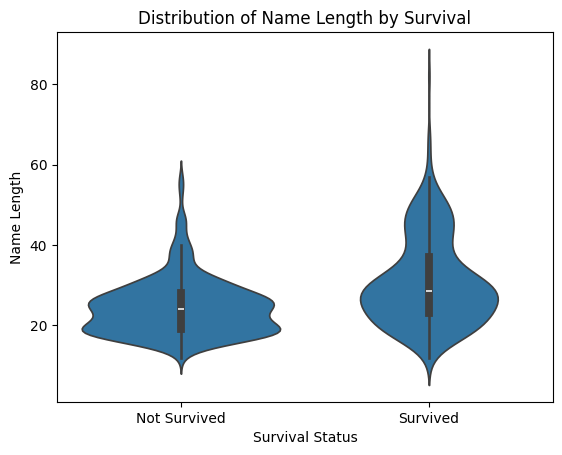

In [39]:
# g = sns.kdeplot(train_df['Name_Length'][(train_df['Survived']==0) & (train_df['Name_Length'].notnull())],color='Red', fill=True)
# g = sns.kdeplot(train_df['Name_Length'][(train_df['Survived']==1) & (train_df['Name_Length'].notnull())],color='Blue', fill=True)
# g.set_xlabel('Name_Length')
# g.set_ylabel('Frequency')
# g = g.legend(['Not Survived', 'Survived'])

sns.violinplot(x="Survived", y="Name_Length", data=train_df)

plt.xticks([0,1], ["Not Survived", "Survived"])
plt.xlabel("Survival Status")
plt.ylabel("Name Length")
plt.title("Distribution of Name Length by Survival")

plt.show()

<Axes: xlabel='Survived', ylabel='Age'>

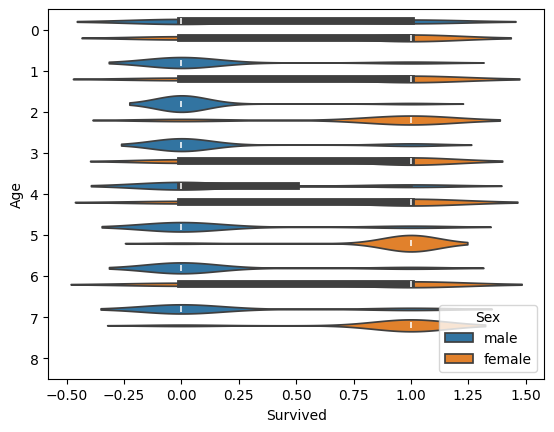

In [40]:
sns.violinplot(x="Survived", y="Age", hue="Sex", data=train_df)

In [41]:
train_df['Name_LengthGB']= pd.qcut(train_df['Name_Length'], 8)
test_df["Name_LengthGB"] = pd.qcut(train_df['Name_Length'], 8)

In [42]:
train_df.groupby(['Name_LengthGB'], as_index = False)['Survived'].mean()

/tmp/ipykernel_55/3439475250.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df.groupby(['Name_LengthGB'], as_index = False)['Survived'].mean()


,Name_LengthGB,Survived
0,"(11.999, 18.0]",0.214286
1,"(18.0, 20.0]",0.252427
2,"(20.0, 23.0]",0.307692
3,"(23.0, 25.0]",0.346939
4,"(25.0, 27.25]",0.292929
5,"(27.25, 30.0]",0.428571
6,"(30.0, 38.0]",0.517241
7,"(38.0, 82.0]",0.745283


In [43]:
bins = [0, 18, 20, 23, 25, 27.25,30, 38, 82,float('inf')]
labels = range(9)

train_df["Name_Size"] = pd.cut(train_df["Name_Length"], bins=bins, labels=labels)
test_df["Name_Size"] = pd.cut(test_df["Name_Length"], bins=bins, labels=labels)

In [44]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Family_Size,Family_Size_Grouped,Age_Cut,Fare_Cut,Title,Name_Length,Name_LengthGB,Name_Size
0,1,0,3,"Braund, Mr. Owen Harris",male,2,1,0,A/5 21171,0,S,2,Small,"(17.0, 22.0]","(-0.001, 7.775]",Mr,23,"(20.0, 23.0]",2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,5,1,0,PC 17599,5,C,2,Small,"(35.0, 45.0]","(52.369, 512.329]",Mrs,51,"(38.0, 82.0]",7
2,3,1,3,"Heikkinen, Miss. Laina",female,3,0,0,STON/O2. 3101282,1,S,1,Alone,"(22.0, 27.0]","(7.775, 8.662]",Miss,22,"(20.0, 23.0]",2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,5,1,0,113803,5,S,2,Small,"(29.0, 35.0]","(52.369, 512.329]",Mrs,44,"(38.0, 82.0]",7
4,5,0,3,"Allen, Mr. William Henry",male,5,0,0,373450,1,S,1,Alone,"(29.0, 35.0]","(7.775, 8.662]",Mr,24,"(23.0, 25.0]",3


In [45]:
train_df['Ticket']

0             A/5 21171
1              PC 17599
2      STON/O2. 3101282
3                113803
4                373450
             ...       
886              211536
887              112053
888          W./C. 6607
889              111369
890              370376
Name: Ticket, Length: 891, dtype: object

In [46]:
train_df["TicketNumber"]= train_df['Ticket'].apply(lambda x: pd.Series({'Ticket': x.split()[-1]}))
test_df["TicketNumber"]= test_df['Ticket'].apply(lambda x: pd.Series({'Ticket': x.split()[-1]}))

In [47]:
train_df.groupby(['TicketNumber'], as_index = False)['Survived'].agg(['count','mean']).sort_values('count', ascending = False)

,TicketNumber,count,mean
94,1601,7,0.714286
196,2343,7,0.000000
464,347082,7,0.000000
468,347088,6,0.000000
358,3101295,6,0.000000
...,...,...,...
276,2667,1,1.000000
278,2669,1,0.000000
279,26707,1,0.000000
280,2671,1,0.000000


In [48]:
train_df['TicketNumberCounts']= train_df.groupby('TicketNumber')['TicketNumber'].transform('count')
test_df['TicketNumberCounts']= test_df.groupby('TicketNumber')['TicketNumber'].transform('count')

In [49]:
train_df.groupby(['TicketNumberCounts'], as_index = False)['Survived'].agg(['count','mean']).sort_values('count', ascending = False)

,TicketNumberCounts,count,mean
0,1,544,0.295956
1,2,188,0.569149
2,3,66,0.712121
3,4,44,0.500000
6,7,21,0.238095
5,6,18,0.000000
4,5,10,0.000000


In [50]:
train_df['Ticket']

0             A/5 21171
1              PC 17599
2      STON/O2. 3101282
3                113803
4                373450
             ...       
886              211536
887              112053
888          W./C. 6607
889              111369
890              370376
Name: Ticket, Length: 891, dtype: object

In [51]:
train_df['Ticket'].str.split(pat=" ", expand=True)

,0,1,2
0,A/5,21171,None
1,PC,17599,None
2,STON/O2.,3101282,None
3,113803,None,None
4,373450,None,None
...,...,...,...
886,211536,None,None
887,112053,None,None
888,W./C.,6607,None
889,111369,None,None


In [52]:
train_df['TicketLocation'] = np.where(train_df['Ticket'].str.split(pat=" ", expand= True)[1].notna(), train_df['Ticket'].str.split(pat=" ", expand=True)[0].apply(lambda x: x.strip()),'Blank')
test_df['TicketLocation'] = np.where(test_df['Ticket'].str.split(pat=" ", expand= True)[1].notna(), test_df['Ticket'].str.split(pat=" ", expand=True)[0].apply(lambda x: x.strip()),'Blank')

In [53]:
train_df['TicketLocation'].value_counts()

TicketLocation
Blank         665
PC             60
C.A.           27
STON/O         12
A/5            10
W./C.           9
CA.             8
SOTON/O.Q.      8
A/5.            7
SOTON/OQ        7
STON/O2.        6
CA              6
C               5
S.O.C.          5
SC/PARIS        5
F.C.C.          5
SC/Paris        4
A/4.            3
PP              3
A/4             3
S.O./P.P.       3
SC/AH           3
A./5.           2
P/PP            2
A.5.            2
WE/P            2
SOTON/O2        2
S.C./PARIS      2
S.C./A.4.       1
Fa              1
S.O.P.          1
SO/C            1
S.P.            1
A4.             1
W.E.P.          1
A/S             1
SC              1
SW/PP           1
SCO/W           1
W/C             1
S.W./PP         1
F.C.            1
C.A./SOTON      1
Name: count, dtype: int64

In [54]:
train_df['TicketLocation'] = train_df['TicketLocation'].replace({
    'SOTON/O.Q.':'SOTON/OQ',
    'C.A.':'CA',
    'CA.':'CA',
    'SC/PARIS':'SC/Paris',
    'S.C./PARIS':'SC/Paris',
    'A/4.':'A/4',
    'A/5.':'A/5',
    'A.5.':'A/5',
    'A./5.':'A/5',
    'W./C.':'W/C',
})

test_df['TicketLocation'] = test_df['TicketLocation'].replace({
    'SOTON/O.Q.':'SOTON/OQ',
    'C.A.':'CA',
    'CA.':'CA',
    'SC/PARIS':'SC/Paris',
    'S.C./PARIS':'SC/Paris',
    'A/4.':'A/4',
    'A/5.':'A/5',
    'A.5.':'A/5',
    'A./5.':'A/5',
    'W./C.':'W/C',
})

In [55]:
train_df.groupby(['TicketLocation'], as_index=False)['Survived'].agg(['count','mean'])

,TicketLocation,count,mean
0,A/4,6,0.000000
1,A/5,21,0.095238
2,A/S,1,0.000000
3,A4.,1,0.000000
4,Blank,665,0.383459
5,C,5,0.400000
6,C.A./SOTON,1,0.000000
7,CA,41,0.341463
8,F.C.,1,0.000000
9,F.C.C.,5,0.800000


In [56]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Family_Size_Grouped,Age_Cut,Fare_Cut,Title,Name_Length,Name_LengthGB,Name_Size,TicketNumber,TicketNumberCounts,TicketLocation
0,1,0,3,"Braund, Mr. Owen Harris",male,2,1,0,A/5 21171,0,...,Small,"(17.0, 22.0]","(-0.001, 7.775]",Mr,23,"(20.0, 23.0]",2,21171,1,A/5
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,5,1,0,PC 17599,5,...,Small,"(35.0, 45.0]","(52.369, 512.329]",Mrs,51,"(38.0, 82.0]",7,17599,1,PC
2,3,1,3,"Heikkinen, Miss. Laina",female,3,0,0,STON/O2. 3101282,1,...,Alone,"(22.0, 27.0]","(7.775, 8.662]",Miss,22,"(20.0, 23.0]",2,3101282,1,STON/O2.
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,5,1,0,113803,5,...,Small,"(29.0, 35.0]","(52.369, 512.329]",Mrs,44,"(38.0, 82.0]",7,113803,2,Blank
4,5,0,3,"Allen, Mr. William Henry",male,5,0,0,373450,1,...,Alone,"(29.0, 35.0]","(7.775, 8.662]",Mr,24,"(23.0, 25.0]",3,373450,1,Blank


In [57]:
train_df.shape

(891, 22)

In [58]:
test_df.shape

(418, 21)

In [59]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   PassengerId          891 non-null    int64   
 1   Survived             891 non-null    int64   
 2   Pclass               891 non-null    int64   
 3   Name                 891 non-null    object  
 4   Sex                  891 non-null    object  
 5   Age                  891 non-null    category
 6   SibSp                891 non-null    int64   
 7   Parch                891 non-null    int64   
 8   Ticket               891 non-null    object  
 9   Fare                 876 non-null    category
 10  Embarked             891 non-null    object  
 11  Family_Size          891 non-null    int64   
 12  Family_Size_Grouped  891 non-null    object  
 13  Age_Cut              891 non-null    category
 14  Fare_Cut             891 non-null    category
 15  Title                89

In [60]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   PassengerId          418 non-null    int64   
 1   Pclass               418 non-null    int64   
 2   Name                 418 non-null    object  
 3   Sex                  418 non-null    object  
 4   Age                  418 non-null    category
 5   SibSp                418 non-null    int64   
 6   Parch                418 non-null    int64   
 7   Ticket               418 non-null    object  
 8   Fare                 415 non-null    category
 9   Embarked             418 non-null    object  
 10  Family_Size          418 non-null    int64   
 11  Family_Size_Grouped  418 non-null    object  
 12  Age_Cut              416 non-null    category
 13  Fare_Cut             417 non-null    category
 14  Title                418 non-null    object  
 15  Name_Length          41

In [61]:
test_df['Fare'] = test_df['Fare'].astype(float)
test_df['Age'] = test_df['Age'].astype(float)
train_df['Age'] = train_df['Age'].astype(float)
train_df['Fare'] = train_df['Fare'].astype(float)

In [62]:
train_df['Age'].fillna(train_df['Age'].mean())
test_df['Age'].fillna(test_df['Age'].mean())
train_df['Fare'] = train_df['Fare'].fillna(train_df['Fare'].median())
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].median())

In [63]:
train_df.isnull().sum()

PassengerId            0
Survived               0
Pclass                 0
Name                   0
Sex                    0
Age                    0
SibSp                  0
Parch                  0
Ticket                 0
Fare                   0
Embarked               0
Family_Size            0
Family_Size_Grouped    0
Age_Cut                0
Fare_Cut               0
Title                  0
Name_Length            0
Name_LengthGB          0
Name_Size              0
TicketNumber           0
TicketNumberCounts     0
TicketLocation         0
dtype: int64

In [64]:
test_df.isnull().sum()

PassengerId            0
Pclass                 0
Name                   0
Sex                    0
Age                    0
SibSp                  0
Parch                  0
Ticket                 0
Fare                   0
Embarked               0
Family_Size            0
Family_Size_Grouped    0
Age_Cut                2
Fare_Cut               1
Title                  0
Name_Length            0
Name_LengthGB          0
Name_Size              0
TicketNumber           0
TicketNumberCounts     0
TicketLocation         0
dtype: int64

In [65]:
ohe = OneHotEncoder(sparse_output=False)
ode = OrdinalEncoder
SI = SimpleImputer(strategy = 'most_frequent')

In [66]:
ode_cols = ['Family_Size_Grouped']
ohe_cols = ['Sex', 'Embarked']
numeric_cols = ['Age', 'Fare']

In [67]:
X = train_df.drop(['Survived'], axis = 1)
y = train_df['Survived']
X_test = test_df.drop(['Age_Cut', 'Fare_Cut'], axis = 1)

In [68]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify = y, random_state = 42)

In [69]:
ord_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy = 'most_frequent')),
    ('ord', OrdinalEncoder(handle_unknown = 'use_encoded_value', unknown_value = -1)),
])


In [70]:
ohe_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy = 'most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown= 'ignore',sparse_output=False))
])


In [71]:
numeric_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy = 'most_frequent')),
     ("scaler", StandardScaler())
])

In [72]:
col_trans = ColumnTransformer(transformers=[
    ('impute', SI, ['Age']),
    ("num", numeric_pipeline, numeric_cols),
    ('ord_pipeline', ord_pipeline, ode_cols),
    ('ohe_pipeline', ohe_pipeline, ohe_cols),
    ('passthrough', 'passthrough', ['Pclass', 'Name_Size', 'Age', 'Fare',  'TicketNumberCounts'])
    ],
    remainder = 'drop',
    n_jobs=-1)

In [73]:
rfc = RandomForestClassifier()

In [74]:
param_grid = {
    'n_estimators': [100,150,200],
    'min_samples_split': [5,10,15],
    'max_depth': [8,9,10,15,20],
    'min_samples_leaf': [1,2,4],
    'criterion': ['gini', 'entropy'],
}

In [75]:
rfc_CV = GridSearchCV(estimator=rfc, param_grid=param_grid, cv=StratifiedKFold(n_splits=5))

In [110]:
rfcfinalpipe = make_pipeline(col_trans, rfc_CV)
rfcfinalpipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(n_jobs=-1,
                                   transformers=[('impute',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['Age']),
                                                 ('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare']),
                                                 ('ord_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                                                   Or...
                                                 ('passthrough', 'passthrough',
                                                  ['Pclass', 'Name_Size', 'Age',
                                                   'Fare',
                                                   'TicketNumberCounts'])])),
                ('gridsearchcv',
                 GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
                              estimator=RandomForestClassifier(),
                              param_grid={'criterion': ['gini', 'entropy'],
                                          'max_depth': [8, 9, 10, 15, 20],
                                          'min_samples_leaf': [1, 2, 4],
                                          'min_samples_split': [5, 10, 15],
                                          'n_estimators': [100, 150, 200]}))])

In [111]:
print(rfc_CV.best_params_)
print(rfc_CV.best_score_)

{'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
0.8385304836009061


In [112]:
dtc = DecisionTreeClassifier()

In [113]:
param_grid = {
    'min_samples_split': [5, 10, 15],
    'max_depth': [10, 20, 30],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy'],
}

In [114]:
dtc_CV = GridSearchCV(estimator=dtc, param_grid=param_grid, cv=StratifiedKFold(n_splits=5))

In [115]:
dtcfinalpipe = make_pipeline(col_trans, dtc_CV)
dtcfinalpipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(n_jobs=-1,
                                   transformers=[('impute',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['Age']),
                                                 ('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare']),
                                                 ('ord_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                                                   Or...
                                                  ['Sex', 'Embarked']),
                                                 ('passthrough', 'passthrough',
                                                  ['Pclass', 'Name_Size', 'Age',
                                                   'Fare',
                                                   'TicketNumberCounts'])])),
                ('gridsearchcv',
                 GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
                              estimator=DecisionTreeClassifier(),
                              param_grid={'criterion': ['gini', 'entropy'],
                                          'max_depth': [10, 20, 30],
                                          'min_samples_leaf': [1, 2, 4],
                                          'min_samples_split': [5, 10, 15]}))])

In [116]:
print(dtc_CV.best_params_)
print(dtc_CV.best_score_)

{'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 15}
0.8315079286910272


In [117]:
X_test.isnull().sum()

PassengerId            0
Pclass                 0
Name                   0
Sex                    0
Age                    0
SibSp                  0
Parch                  0
Ticket                 0
Fare                   0
Embarked               0
Family_Size            0
Family_Size_Grouped    0
Title                  0
Name_Length            0
Name_LengthGB          0
Name_Size              0
TicketNumber           0
TicketNumberCounts     0
TicketLocation         0
dtype: int64

In [118]:
knn = KNeighborsClassifier()

In [119]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'p': [1,2],
}

In [120]:
knn_CV = GridSearchCV(estimator=knn, param_grid=param_grid, cv=StratifiedKFold(n_splits=5))

In [121]:
knnfinalpipe = make_pipeline(col_trans, knn_CV)
knnfinalpipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(n_jobs=-1,
                                   transformers=[('impute',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['Age']),
                                                 ('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare']),
                                                 ('ord_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                                                   Or...
                                                 ('passthrough', 'passthrough',
                                                  ['Pclass', 'Name_Size', 'Age',
                                                   'Fare',
                                                   'TicketNumberCounts'])])),
                ('gridsearchcv',
                 GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
                              estimator=KNeighborsClassifier(),
                              param_grid={'algorithm': ['auto', 'ball_tree',
                                                        'kd_tree', 'brute'],
                                          'n_neighbors': [3, 5, 7, 9, 11],
                                          'p': [1, 2],
                                          'weights': ['uniform',
                                                      'distance']}))])

In [123]:
print(knn_CV.best_params_)
print(knn_CV.best_score_)

{'algorithm': 'brute', 'n_neighbors': 7, 'p': 1, 'weights': 'uniform'}
0.8034669555796317


In [124]:
svc = SVC(probability=True)

In [125]:
param_grid = {
    'C': [100,10, 1.0, 0.1, 0.001, 0.001],
    'kernel':['linear', 'poly', 'rbf', 'sigmoid'],
}

In [126]:
svc_CV = GridSearchCV(estimator=svc, param_grid=param_grid, cv=StratifiedKFold(n_splits=5))


In [132]:
pipefinalsvc = make_pipeline(col_trans, svc_CV)
pipefinalsvc.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(n_jobs=-1,
                                   transformers=[('impute',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['Age']),
                                                 ('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare']),
                                                 ('ord_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                                                   Or...
                                                                                 sparse_output=False))]),
                                                  ['Sex', 'Embarked']),
                                                 ('passthrough', 'passthrough',
                                                  ['Pclass', 'Name_Size', 'Age',
                                                   'Fare',
                                                   'TicketNumberCounts'])])),
                ('gridsearchcv',
                 GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
                              estimator=SVC(probability=True),
                              param_grid={'C': [100, 10, 1.0, 0.1, 0.001,
                                                0.001],
                                          'kernel': ['linear', 'poly', 'rbf',
                                                     'sigmoid']}))])

In [133]:
print(svc_CV.best_params_)
print(svc_CV.best_score_)

{'C': 10, 'kernel': 'poly'}
0.8272727272727274


In [134]:
lr = LogisticRegression()

In [135]:
param_grid = {
    'C': [100,10, 1.0, 0.1, 0.001, 0.001],
}

In [136]:
lr_CV = GridSearchCV(estimator=lr, param_grid=param_grid, cv=StratifiedKFold(n_splits=5))

In [137]:
lrfinalpipe= make_pipeline(col_trans, lr_CV)
lrfinalpipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(n_jobs=-1,
                                   transformers=[('impute',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['Age']),
                                                 ('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare']),
                                                 ('ord_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                                                   Or...
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Sex', 'Embarked']),
                                                 ('passthrough', 'passthrough',
                                                  ['Pclass', 'Name_Size', 'Age',
                                                   'Fare',
                                                   'TicketNumberCounts'])])),
                ('gridsearchcv',
                 GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
                              estimator=LogisticRegression(),
                              param_grid={'C': [100, 10, 1.0, 0.1, 0.001,
                                                0.001]}))])

In [138]:
print(lr_CV.best_params_)
print(lr_CV.best_score_)

{'C': 0.1}
0.796385304836009


In [139]:
gnb = GaussianNB()

In [140]:
param_grid = {
    'var_smoothing': [0.00000001, 0.000000001, 0.00000001],
}

In [141]:
gnb_CV = GridSearchCV(estimator=gnb, param_grid=param_grid, cv=StratifiedKFold(n_splits=5))


In [142]:
gnbfinalpipe= make_pipeline(col_trans, gnb_CV)
gnbfinalpipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(n_jobs=-1,
                                   transformers=[('impute',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['Age']),
                                                 ('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare']),
                                                 ('ord_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                                                   Or...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Sex', 'Embarked']),
                                                 ('passthrough', 'passthrough',
                                                  ['Pclass', 'Name_Size', 'Age',
                                                   'Fare',
                                                   'TicketNumberCounts'])])),
                ('gridsearchcv',
                 GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
                              estimator=GaussianNB(),
                              param_grid={'var_smoothing': [1e-08, 1e-09,
                                                            1e-08]}))])

In [143]:
print(gnb_CV.best_params_)
print(gnb_CV.best_score_)

{'var_smoothing': 1e-08}
0.7767457894218458


In [144]:
Y_pred = rfcfinalpipe.predict(X_test)
Y_pred2 = dtcfinalpipe.predict(X_test)
Y_pred3 = knnfinalpipe.predict(X_test)
Y_pred4 = pipefinalsvc.predict(X_test)
Y_pred5 = lrfinalpipe.predict(X_test)
Y_pred6 = gnbfinalpipe.predict(X_test)

In [145]:
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': Y_pred
})

submission2 = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': Y_pred2
})

submission3 = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': Y_pred3
})

submission4 = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': Y_pred4
})

submission5 = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': Y_pred5
})

submission6 = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': Y_pred6
})

In [146]:
submission.to_csv('/kaggle/working/submission_1.csv', index=False)
submission2.to_csv('/kaggle/working/submission_2.csv', index=False)
submission3.to_csv('/kaggle/working/submission_3.csv', index=False)
submission4.to_csv('/kaggle/working/submission_4.csv', index=False)
submission5.to_csv('/kaggle/working/submission_5.csv', index=False)
submission6.to_csv('/kaggle/working/submission_6.csv', index=False)

In [147]:
import joblib

In [148]:
models = {
    "rfc": rfcfinalpipe,
    "knn": knnfinalpipe,
    "svc": pipefinalsvc,
    "gnb": gnbfinalpipe,
    "lr": lrfinalpipe,
    "dtc": dtcfinalpipe
}

for name, model in models.items():
    joblib.dump(model, f"{name}_model.pkl")